# Figure 3 | VIMFC regression and decomposition

This notebook combines the VIMFC-regression maps with the regional VIMFC decomposition. It reads the VIMFC cache and decomposition table stored in this directory and writes the final figure as `fig3_vimfc_decomp.png`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import gaussian_filter

# Global typography — change this one value to resize all labels and titles.
PLOT_FONTSIZE = 16
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': PLOT_FONTSIZE,
    'axes.titlesize': PLOT_FONTSIZE,
    'axes.labelsize': PLOT_FONTSIZE,
    'xtick.labelsize': PLOT_FONTSIZE,
    'ytick.labelsize': PLOT_FONTSIZE,
})

FIG_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig3')
MFC_PATH = FIG_DIR / 'mfc_reg_cache_1981_2025.nc'
DECOMP_PATH = FIG_DIR / 'dekomposisi_mfc_data.csv'
OUTPUT_PATH = FIG_DIR / 'fig3_vimfc_decomp_sig.png'

mfc_ds = xr.open_dataset(MFC_PATH)
decomp_df = pd.read_csv(DECOMP_PATH).set_index('term')

mfc_plot_scale = 1e6
mc_extent = [60, 180, -30, 30]
vimfc_domain = [95, 125, -6, 2]
mc_xticks = [60, 90, 120, 150, 180]
mc_yticks = [-30, -20, -10, 0, 10, 20, 30]
mfc_step = 18
sig_step = 12
levels = np.arange(-30, 30.0 + 2.5 / 2, 2.5)
ticks = np.arange(-30, 30.0 + 5 / 2, 5)
colorbar_label = r'$10^{-6}$ kg m$^{-2}$ s$^{-1}$ per 1$\sigma$ Niño 3.4'


In [2]:
def subset_domain(da):
    """Select the maritime-continent domain regardless of coordinate order."""
    lon_slice = slice(60, 180) if da.lon.values[0] <= da.lon.values[-1] else slice(180, 60)
    lat_slice = slice(-30, 30) if da.lat.values[0] <= da.lat.values[-1] else slice(30, -30)
    return da.sel(lon=lon_slice, lat=lat_slice)


def smooth_nan_safe(da, sigma=0.8):
    mask = np.isfinite(da.values)
    weights = gaussian_filter(mask.astype(float), sigma=sigma)
    filtered = gaussian_filter(np.where(mask, da.values, 0.0), sigma=sigma)
    with np.errstate(invalid='ignore', divide='ignore'):
        values = filtered / weights
    values[weights <= 0] = np.nan
    return xr.DataArray(values, coords=da.coords, dims=da.dims, name=da.name)


def add_map(ax, shade, u, v, sig_mask, scale, key_u, key_label, title, cmap):
    shade = smooth_nan_safe(subset_domain(shade).reset_coords(drop=True))
    image = shade.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, levels=levels,
        extend='both', add_colorbar=False, add_labels=False, infer_intervals=True,
    )

    u_plot = subset_domain(u).isel(lat=slice(None, None, mfc_step), lon=slice(None, None, mfc_step))
    v_plot = subset_domain(v).isel(lat=slice(None, None, mfc_step), lon=slice(None, None, mfc_step))
    quiver = ax.quiver(
        u_plot.lon.values, u_plot.lat.values, u_plot.values, v_plot.values,
        transform=ccrs.PlateCarree(), scale=scale, scale_units='width', width=0.0025,
        headwidth=8 * (0.0020 / 0.0025), headlength=8 * (0.0020 / 0.0025),
        headaxislength=7 * (0.0020 / 0.0025), minshaft=0, minlength=0,
        color='black', zorder=4,
    )

    # Quiver-key controls (matching Fig. 4). Edit these axes-fraction values only
    # when the white key box or reference arrow needs repositioning.
    key_box = mpatches.Rectangle(
        (quiver_key_box_x, quiver_key_box_y), quiver_key_box_width, quiver_key_box_height,
        transform=ax.transAxes, facecolor='white', edgecolor='none', alpha=1, zorder=5,
    )
    ax.add_patch(key_box)
    key = ax.quiverkey(
        quiver, X=quiver_key_x, Y=quiver_key_y, U=key_u, label=key_label, labelpos='W',
        coordinates='axes', color='black',
        fontproperties={'size': PLOT_FONTSIZE, 'weight': 'bold'}, labelsep=0.1,
    )
    key.set_zorder(6)
    key.text.set_zorder(7)

    # Figure 4-style stippling: retain a marker for each significant coarse cell.
    sig_plot = subset_domain(sig_mask.fillna(False).astype(np.int8))
    sig_plot = sig_plot.coarsen(lat=sig_step, lon=sig_step, boundary='trim').max() > 0
    yy, xx = np.where(sig_plot.values)
    if yy.size > 0:
        ax.scatter(
            sig_plot['lon'].values[xx], sig_plot['lat'].values[yy],
            s=12, c='k', marker='.', linewidths=0, alpha=0.55,
            transform=ccrs.PlateCarree(), zorder=4,
        )

    ax.coastlines(resolution='50m', linewidth=0.6, color='black', zorder=3)
    ax.set_extent(mc_extent, crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, xlocs=mc_xticks, ylocs=mc_yticks, linewidth=0.3,
                 color='gray', alpha=0.4, linestyle='--')
    ax.set_xticks(mc_xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(mc_yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    # Keep the edge longitude labels inside the map frame.
    for tick, label in zip(mc_xticks, ax.get_xticklabels()):
        if tick == 60:
            label.set_horizontalalignment('left')
        elif tick == 180:
            label.set_horizontalalignment('right')
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelright=False, labelsize=PLOT_FONTSIZE)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title, loc='left', fontweight='bold', pad=12)
    return image


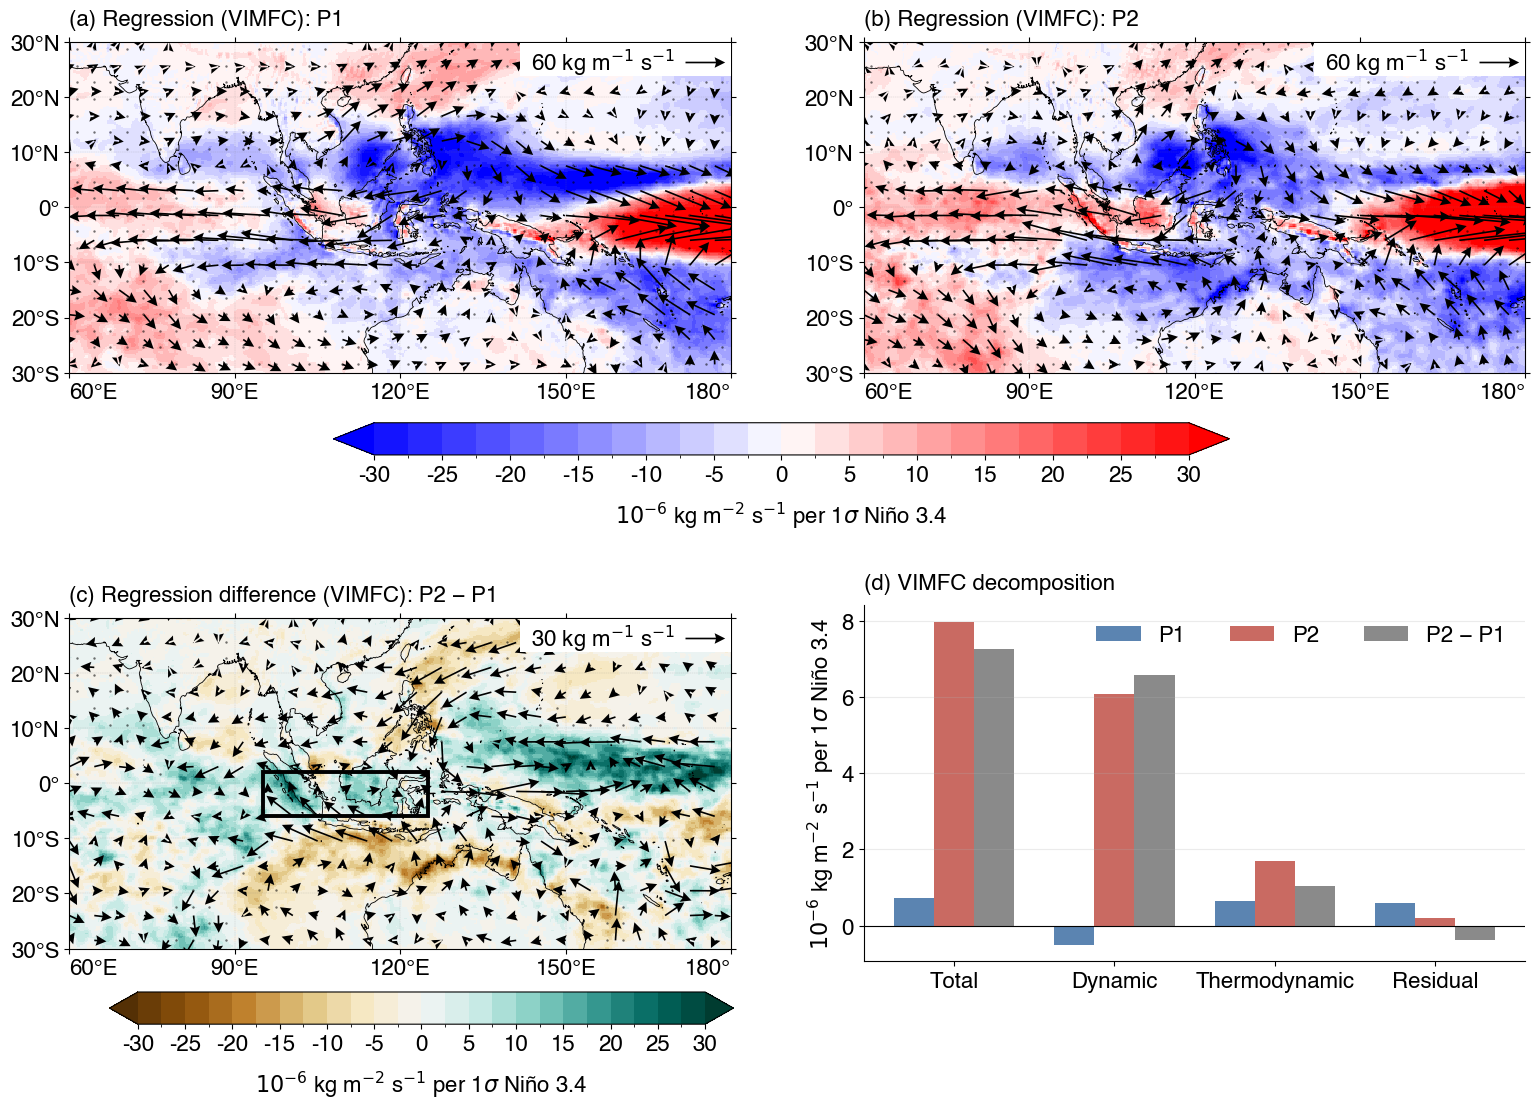

Saved figure to /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig3/fig3_vimfc_decomp_sig.png


In [3]:


# =========================
# MANUAL LAYOUT CONTROLS
# =========================
# These values mirror the Fig. 4 plotting style. Adjust them here rather than
# changing the plotting commands below.
fig_width = 16
fig_height = 11.5
fig_left, fig_right = 0.055, 0.965
fig_bottom, fig_top = 0.12, 0.93
subplot_wspace, subplot_hspace = 0.20, 0.62

# Quiver key: Fig. 4's neatly aligned upper-right in-map reference box.
quiver_key_box_x, quiver_key_box_y = 0.68, 0.8975
quiver_key_box_width, quiver_key_box_height = 0.32, 0.10
quiver_key_x, quiver_key_y = 0.93, 0.94

# Horizontal colorbar geometry: [left, bottom, width, height] in figure fractions.
top_cbar_rect = [0.22, 0.56, 0.56, 0.028]
diff_cbar_rect = [0.08, 0.065, 0.39, 0.028]

fig = plt.figure(figsize=(fig_width, fig_height))
gs = gridspec.GridSpec(2, 2, figure=fig, left=fig_left, right=fig_right,
                       bottom=fig_bottom, top=fig_top, wspace=subplot_wspace,
                       hspace=subplot_hspace)

ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
ax_b = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
ax_c = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
ax_d = fig.add_subplot(gs[1, 1])

top_image = add_map(
    ax_a, mfc_ds['mfc_reg_past'] * mfc_plot_scale, mfc_ds['mfc_qx_reg_past'], mfc_ds['mfc_qy_reg_past'],
    mfc_ds['mfc_vector_sig_past'],
    1000, 60, r'60 kg m$^{-1}$ s$^{-1}$', '(a) Regression (VIMFC): P1', 'bwr',
)
add_map(
    ax_b, mfc_ds['mfc_reg_recent'] * mfc_plot_scale, mfc_ds['mfc_qx_reg_recent'], mfc_ds['mfc_qy_reg_recent'],
    mfc_ds['mfc_vector_sig_recent'],
    1000, 60, r'60 kg m$^{-1}$ s$^{-1}$', '(b) Regression (VIMFC): P2', 'bwr',
)
diff_image = add_map(
    ax_c, mfc_ds['mfc_reg_recent_minus_past'] * mfc_plot_scale,
    mfc_ds['mfc_qx_reg_recent_minus_past'], mfc_ds['mfc_qy_reg_recent_minus_past'],
    mfc_ds['mfc_vector_sig_recent_minus_past'],
    500, 30, r'30 kg m$^{-1}$ s$^{-1}$', '(c) Regression difference (VIMFC): P2 − P1', 'BrBG',
)
# Same VIMFC analysis domain highlighted in Figure 2 panel (c).
ax_c.add_patch(mpatches.Rectangle(
    (vimfc_domain[0], vimfc_domain[2]),
    vimfc_domain[1] - vimfc_domain[0],
    vimfc_domain[3] - vimfc_domain[2],
    fill=False, edgecolor='black', linewidth=2.8,
    transform=ccrs.PlateCarree(), zorder=5,
))

# Shared P1/P2 colour bar, placed in the central gutter beneath the upper maps.
top_cax = fig.add_axes(top_cbar_rect)
top_cbar = fig.colorbar(top_image, cax=top_cax, orientation='horizontal', ticks=ticks, extend='both')
top_cbar.set_label(colorbar_label, labelpad=10, fontsize=PLOT_FONTSIZE)

# Difference colour bar beneath panel c.
diff_cax = fig.add_axes(diff_cbar_rect)
diff_cbar = fig.colorbar(diff_image, cax=diff_cax, orientation='horizontal', ticks=ticks, extend='both')
diff_cbar.set_label(colorbar_label, labelpad=10, fontsize=PLOT_FONTSIZE)
for cbar in (top_cbar, diff_cbar):
    cbar.ax.tick_params(labelsize=PLOT_FONTSIZE)
    cbar.ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))

# Decomposition chart.
terms = ['total', 'dynamic', 'thermodynamic', 'residual']
term_labels = ['Total', 'Dynamic', 'Thermodynamic', 'Residual']
x = np.arange(len(terms))
width = 0.25
series = [
    ('P1', 'P1_kg_m2_s', -width, '#5B84B1'),
    ('P2', 'P2_kg_m2_s', 0.0, '#C96A62'),
    ('P2 − P1', 'diff_P2_minus_P1_kg_m2_s', width, '#8A8A8A'),
]
for label, column, offset, color in series:
    ax_d.bar(x + offset, decomp_df.loc[terms, column].to_numpy() * mfc_plot_scale, width=width,
             label=label, color=color)
ax_d.axhline(0, color='black', linewidth=0.8)
ax_d.set_xticks(x, term_labels)
# Values are scaled to 10^-6 so the scientific-notation offset is part of the y-axis label.
ax_d.set_ylabel(r'$10^{-6}$ kg m$^{-2}$ s$^{-1}$ per 1$\sigma$ Niño 3.4')
ax_d.set_title('(d) VIMFC decomposition', loc='left', fontweight='bold', pad=12)
ax_d.tick_params(axis='both', labelsize=PLOT_FONTSIZE)
ax_d.legend(frameon=False, ncol=3, fontsize=PLOT_FONTSIZE, loc='upper right')
ax_d.grid(axis='y', alpha=0.25)
ax_d.spines[['top', 'right']].set_visible(False)

fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved figure to {OUTPUT_PATH}')
